In [144]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import lib.plotGraph as plotGraph
import lib.ioFile as ioFile
import lib.powerfun as powerfun
import lib.graph as graph
import lib.threshold as threshold
import lib.residual as resd
import lib.subBase as subBase
import lib.utils as utils
import lib.ac_se_fdia as ac_se_fdia
from skimage.filters import threshold_li
import pandas as pd
import lib.cycle_space as csp
import tqdm
from scipy.stats import chi2
from lib.read_ac_pf_csv import read_load_gen_data
from scipy.linalg import qr
import pandapower as pp
import pandapower.networks as nw
import warnings
warnings.filterwarnings("ignore")

mode= "AC" 
powerID= 14
IEEENames= ["IEEE 14", "IEEE 30", "IEEE 57", "IEEE 118"]
case_map = {14: nw.case14, 30: nw.case30, 57: nw.case57, 118: nw.case118}
net = case_map[powerID]()
outPutFile= False
datasource= "open" #open, matpower
# Load MATLAB file
opensource_file= f"C:/Users/30678/Desktop/large_files/ac_power_flow_data/pglib_opf_case{powerID}_ieee.csv"
matpower_file= f'matpower/test_data/{mode}_case{powerID}_.mat' #14, 118, 57, 30
Chenhan_file= f"data/ac/results{powerID}_AC.xlsx"
DC_file= f'data/paper_2/results{powerID}.xlsx' # DC
#
_, _, H, A, qfData, resistance, voltage, reactance= ioFile.read_mat_power(matpower_file, normalize= False)
pfDataDc, _=ioFile.read_excel_power(DC_file, id1= 0, id2= 0)
loadP, loadQ= read_load_gen_data(opensource_file, 10)
param= np.sum(np.abs(H), axis= 1, keepdims= True)/2
m= H.shape[0]
n= H.shape[1]
rankH= n-1
stdOfNoise= 1e-3
numTrain= m
if powerID== 30:
    choosingLoad= [i for i in range(loadP.shape[1]) if i!=3]
    loadP= loadP[:, choosingLoad]
    loadQ= loadQ[:, choosingLoad]
num_scenarios= loadP.shape[0]
num_loads = loadP.shape[1]
print(loadP.shape)
voltage = []
phaseAngle= []
pfDataF= []
pfDataT= []
qfDataF= []
qfDataT= []
pfBus= []
qfBus= []
original_power_flows= [(int(A[i].argmax()), int(A[i].argmin())) for i in range(A.shape[0])]
linkMapping= ac_se_fdia.map_branches_to_pandapower(net, original_power_flows)
for i in tqdm.tqdm(range(num_scenarios)):
    # Get the load data for the current scenario (i-th row)
    current_p_mw = loadP[i, :]
    current_q_mvar = loadQ[i, :]
    # Update the pandapower network's load DataFrame
    # We update the first 21 loads in the network

    # net.load.p_mw.iloc[:num_loads] = current_p_mw
    # net.load.q_mvar.iloc[:num_loads] = current_q_mvar

    # Run the AC power flow for this scenario
    try:
        pp.runpp(net, init= "flat", verbose=False, zero_injection=None)

        # If successful, store the desired results.
        # Here, we store the bus voltage magnitudes.
        voltage.append(net.res_bus.vm_pu.copy())
        phaseAngle.append(net.res_bus.va_degree.copy())
        pfBus.append(net.res_bus.p_mw.copy())
        qfBus.append(net.res_line.q_from_mvar.copy())
        pfDataFt= []
        pfDataTt= []
        qfDataFt= []
        qfDataTt= []
        for branch in range(m):
            newIdx= linkMapping[branch]["index"]
            if linkMapping[branch]["type"]== "line":
                # no to-end provided in this quick demo
                pfDataFt.append(net.res_line.p_from_mw.loc[newIdx])
                pfDataTt.append(net.res_line.p_to_mw.loc[newIdx])
                qfDataFt.append(net.res_line.q_from_mvar.loc[newIdx])
                qfDataTt.append(net.res_line.q_to_mvar.loc[newIdx])
            else:
                pfDataFt.append(net.res_trafo.p_hv_mw.loc[newIdx])
                pfDataTt.append(net.res_trafo.p_lv_mw.loc[newIdx])
                qfDataFt.append(net.res_trafo.q_hv_mvar.loc[newIdx])
                qfDataTt.append(net.res_trafo.q_lv_mvar.loc[newIdx])
        pfDataF.append(np.array(pfDataFt))
        pfDataT.append(np.array(pfDataTt))
        qfDataF.append(np.array(qfDataFt))
        qfDataT.append(np.array(qfDataTt))
    except pp.LoadflowNotConverged:
        # Handle cases where the power flow does not converge
        print(f"Power flow for scenario {i} did not converge.")
voltage = np.stack(voltage)
phaseAngle= np.stack(phaseAngle)/180*np.pi
pfDataF= np.stack(pfDataF)
pfDataT= np.stack(pfDataT)
qfDataF= np.stack(qfDataF)
qfDataT= np.stack(qfDataT)
pfBus= np.stack(pfBus)
qfBus= np.stack(qfBus)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


INFO:pandapower.convert_format:These dtypes could not be corrected: {'gen': ['id_q_capability_characteristic'], 'shunt': ['id_characteristic_table']}


(10, 11)


100%|██████████| 10/10 [00:00<00:00, 59.62it/s]


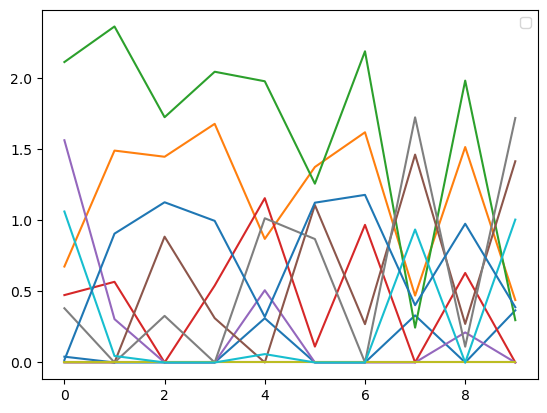

In [145]:
plt.plot(loadQ)
plt.legend()

In [75]:
# timIdx= 3
# print(loadP[timIdx, :])
# print(loadQ[timIdx, :])
# net= nw.case14()
# print(net.load)

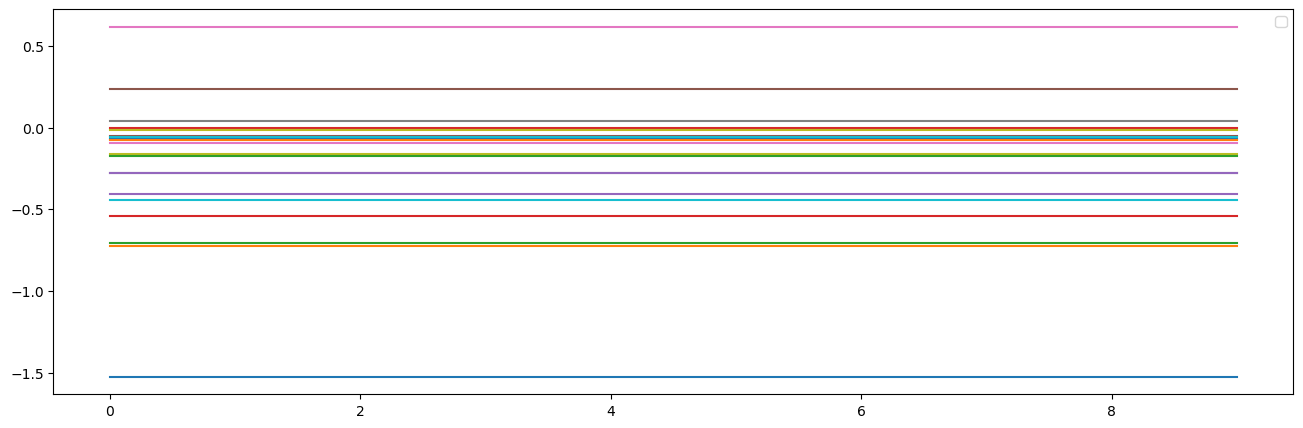

In [146]:
plt.figure(figsize=(16, 5))
plt.plot(pfDataT/100)
plt.legend()

In [148]:
timIdx= 1
# Count the number of lines
num_lines = len(net.line)
# Count the number of transformers
num_trafos = len(net.trafo)
print(num_lines, num_trafos)
# Use a subset as "measurements"
bus_inj = []
for b in range(A.shape[1]):
    p =  float(pfBus[timIdx][b])
    q =  float(qfBus[timIdx][b])
    bus_inj.append([b, p, q])
branch = []
transformers= []
# For a few lines, take from-end flows
for line_idx in range(A.shape[0]):
    newIdx= linkMapping[line_idx]["index"]
    p_from = float(pfDataF[timIdx][newIdx])
    q_from = float(qfDataF[timIdx][newIdx])
    p_to = float(pfDataT[timIdx][newIdx])
    q_to = float(qfDataT[timIdx][newIdx])
    if linkMapping[line_idx]["type"]== "line":
        # no to-end provided in this quick demo
        branch.append([newIdx, p_from, q_from, p_to, q_to])
    else:
        transformers.append([newIdx, p_from, q_from, p_to, q_to])
# net.measurement.drop(net.measurement.index, inplace=True)
statePred = ac_se_fdia.estimate_state(
    net,
    bus_injections=np.array(bus_inj, dtype=float),
    branch_flows=np.array(branch, dtype=object),
    transformers=np.array(transformers, dtype=object),
    std_p= 1e-2,
    std_q= 1e-2,
    init="flat", 
    algorithm= "wls")
# print(statePred["converged"])
# print(statePred["iterations"])
print(phaseAngle[timIdx]*180/np.pi)
print(statePred["va_degree"])
# phaseAngle[timIdx]= statePred["va_degree"]/180*np.pi

15 5


DEBUG:pandapower.estimation.state_estimation:State Estimation successful (11 iterations)


[  0.          -4.98258914 -12.72509994 -10.31290109  -8.7738539
 -14.22094646 -13.35962737 -13.35962737 -14.9385213  -15.09728846
 -14.79062203 -15.07558452 -15.15627634 -16.03364453]
[  0.          -3.61649898  -9.07686654  -8.48659762  -7.17094548
 -14.40564472 -16.1474471  -18.96298484 -17.41212376 -17.60150466
 -16.94241225 -15.29677801 -15.99587811 -18.55517095]


In [108]:
# valide AC power flow
pfDataR= pfDataF*0
for branchId in range(pfDataF.shape[1]):
    BId= -1/reactance[branchId]
    busI= np.argmin(A[branchId, :])
    busJ= np.argmax(A[branchId, :])
    resistanceId= resistance[branchId]
    VI= voltage[:, busI]
    VJ= voltage[:, busJ]
    thetaI= phaseAngle[:, busI]
    thetaJ= phaseAngle[:, busJ]
    acData= pfDataF[:, branchId]
    acQData= qfData[:, branchId]
    acInfP= VI*VJ*(resistanceId*np.cos(thetaI-thetaJ)-BId*np.sin(thetaI-thetaJ))-VI*VI*resistanceId
    # acInfP= acInfP/(VI*VJ)
    pfDataR[:, branchId]= acInfP
    pass
# pfData= pfDataR
branchId= 11
timeId= [timIdx]
BId= -1/reactance[branchId] # X
resistanceId= resistance[branchId]
busI= np.argmin(A[branchId, :])
busJ= np.argmax(A[branchId, :])
VI= voltage[timeId, busI]
VJ= voltage[timeId, busJ]
thetaI= phaseAngle[timeId, busI]
thetaJ= phaseAngle[timeId, busJ]
acData= pfDataF[timeId, branchId]
acQData= qfData[timeId, branchId]
acInfP= VI*VJ*(resistanceId*np.cos(thetaI-thetaJ)-BId*np.sin(thetaI-thetaJ))-VI*VI*resistanceId
dcInfP= -VI*VJ*(thetaI-thetaJ)*BId
acInfQ= VI*VJ*(resistanceId*np.sin(thetaI-thetaJ)-BId*np.cos(thetaI-thetaJ))+VI*VI*BId
dcInfQ= -VI*VJ*BId*np.cos(thetaI-thetaJ)+VI*VI*BId
print()
print(acData/100)
print(acInfP)
print(dcInfP)
# print()
# print(acQData)
# print(acInfQ)
# print(dcInfQ)


[0.2354158]
[-0.17113737]
[-0.17564835]


In [130]:
#extract fundamental cycles from DC power flow
noiseVector= np.random.randn(pfDataDc.shape[0], pfDataDc.shape[1])
noiseE= noiseVector*1e-5
pfDataDcNoise= pfDataDc+noiseE
wholeRight= pfDataDcNoise[:numTrain, :].T.dot(pfDataDcNoise[:numTrain, :])
spaningTreeList, leftLinksSet= csp.get_spanning_tree(pfDataDcNoise[:numTrain, :], rankH, m)
cycleList, treeLinks= csp.get_cycle_and_tree(spaningTreeList, leftLinksSet, wholeRight, m)
_, cSpaceClean, _= resd.cycle_residual(pfDataF[:numTrain, :], rankH, m, pfDataF[numTrain:, :], cycleList)
NcSpaceClean= cSpaceClean@np.linalg.pinv(cSpaceClean.T@cSpaceClean)@cSpaceClean.T
for cycle in cycleList:
    print(len(cycle)-np.linalg.matrix_rank(H[list(cycle), :]), end=" ")
    pass
# cycleList= [{0, 1, 4}, {2, 4, 5, 6}, {3, 4, 6}, {8, 14, 7}, {6, 7, 9, 10, 14, 15, 17}, {18, 11, 12}, {10, 12, 15, 16, 17, 19}]
print()
print(cycleList)

1 1 1 1 1 1 1 
[{0, 1, 4}, {2, 4, 5, 6}, {3, 4, 6}, {8, 14, 7}, {6, 7, 9, 10, 14, 15, 17}, {18, 11, 12}, {10, 12, 15, 16, 17, 19}]


In [131]:
for k in range(5):
    countT= 0
    for i in range(len(cycleList)):
        for j in range(i+1, len(cycleList)):
            c1= cycleList[i]
            c2= cycleList[j]
            intersect= c1&c2
            left1= c1-intersect
            left2= c2-intersect
            if len(left1)<len(intersect):
                cycleList[j]= left1|left2
                countT+=(len(intersect)-len(left1))
            elif len(left2)<len(intersect):
                cycleList[i]= left1|left2
                countT+=(len(intersect)-len(left2))
    print(countT)
print(cycleList)
for cycle in cycleList:
    print(len(cycle)-np.linalg.matrix_rank(H[list(cycle), :]), end=" ")
    pass

2
0
0
0
0
[{0, 1, 4}, {2, 3, 5}, {3, 4, 6}, {8, 14, 7}, {17, 6, 8, 9, 10, 15}, {18, 11, 12}, {10, 12, 15, 16, 17, 19}]
1 1 1 1 1 1 1 

In [ ]:
# tmpPdData= (H@simuX.T).T+noiseVector*1e-5
def get_indicators(tmpPfData):
    cycleRight= tmpPfData.T@(tmpPfData)
    Val, Vt = np.linalg.eigh(cycleRight)
    Val= np.abs(np.real(Val))
    Val= Val/np.linalg.norm(Val)
    UT= np.abs(Vt[:, 0][:, None])
    maxminPara= np.max(UT)/np.min(UT)
    minSingVal= Val[0]
    return maxminPara, minSingVal
def reduce_cycle_branch():
    pass
ratiosStd= []
residuals= []
indicator= []
indicator2= []
errorDistributionDc= []
errorDistributionCyc= []
cycleLists= [list(i) for i in cycleList]
linkPairs= set()
cSpaces= []
for id, choosenCycle in enumerate(cycleLists):
    choosenCycle= list(choosenCycle)
    # print(choosenCycle)
    subH= H[choosenCycle, :]
    subH= subH[:, ~np.all(subH== 0, axis=0)]
    subA= A[choosenCycle, :]
    subA= subA[:, ~np.all(subA== 0, axis=0)]
    cyclePfData= pfDataF[:, choosenCycle]
    cycLen= cyclePfData.shape[1]
    subPara= param[choosenCycle]
    cycLen= cyclePfData.shape[1]
    squareRatio= np.zeros((cycLen, cycLen))+np.nan
    sameFlag= 0
    for i in range(cycLen): # remove linear dependent links
        for j in range(i):
            if cycLen>2:
                if get_indicators(cyclePfData[:, [i, j]])[1]<1e-5: 
                    sameFlag= 1
                    linkPairs.add((choosenCycle[i], choosenCycle[j]))
                    # print("ij:", i, " ", j)
                    # print("ij:", choosenCycle[i], " ", choosenCycle[j])
    _, _, pivot = qr(cyclePfData, pivoting=True)
    maxminPara, minSingVal= get_indicators(cyclePfData)
    cycleRight= cyclePfData.T@(cyclePfData)
    Val, Vt = np.linalg.eigh(cycleRight)
    Val= np.abs(np.real(Val))
    Val= Val/np.linalg.norm(Val)
    indicator.append(Val[0])
    indicator2.append(Val[0]/Val[1])
    # print()
    UT= Vt[:, 0][:, None]
    tmpi= 0
    while maxminPara>100 and minSingVal<1e-6:
        tmpi+=1
        UT= Vt[:, tmpi][:, None]
        maxminPara= np.max(np.abs(UT))/np.min(np.abs(UT))
    # print(UT)
    # print(cyclePfData.shape)
    dcSpace= np.sign(UT)/subPara
    dcSpace= dcSpace/np.linalg.norm(dcSpace)
    errorDistributionDc.append(cyclePfData@dcSpace)
    errorDistributionCyc.append(cyclePfData@UT)
    # print(np.linalg.norm(dcSpace))
    # print(np.linalg.norm(UT))
    line_parameter= np.abs(1/UT[:, -1][:, None])
    ratio= (line_parameter/subPara)[:, 0]
    if tmpi and sameFlag==0:
        print(choosenCycle)
        print(minSingVal)
        # print("pivot,",pivot)
        # print(np.round(squareRatio, 2)-1)
        # print(Val)
        # print(np.std(ratio))
        print(id)
        # print()
    # print(np.std(ratio))
    ratiosStd.append(1e-4+np.std(ratio))
    # print(sortedVal)
    # print(ratio)
    # print(Val)
    cSpaceT= UT[:, -1][:, None]
    cSpaces.append(cSpaceT)
    residuals.append(np.mean(np.abs(cyclePfData@cSpaceT)))